# Cohort Analysis & Sales Analysis

## Objetivo

Entender el comportamiento de retención de clientes a lo largo del 
tiempo y evaluar el rendimiento de ventas por producto y mercado.

## Estructura del notebook

1. **Análisis de cohortes**: retención mensual de clientes agrupados 
   por mes de primera compra. Base: `df_customers`.
2. **Análisis de ventas**: rendimiento por producto y país. 
   Base: `df_clean`.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

ECOMMERCE_PATH = os.path.join('..', 'data', 'eCommerce_Dataset.csv')
OUTPUTS_DIR    = os.path.join('..', 'outputs')

df_ecom = pd.read_csv(ECOMMERCE_PATH, encoding='ISO-8859-1')

cancelled  = df_ecom['InvoiceNo'].str.startswith('C')
qty_ok     = df_ecom['Quantity'] > 0
price_ok   = df_ecom['UnitPrice'] > 0

df_clean = (
    df_ecom
    .drop_duplicates()
    .loc[~cancelled & qty_ok & price_ok]
    .copy()
)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['revenue']     = df_clean['Quantity'] * df_clean['UnitPrice']

df_customers = df_clean.dropna(subset=['CustomerID']).copy()
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)

print(f"df_clean:     {df_clean.shape}")
print(f"df_customers: {df_customers.shape}")

df_clean:     (524878, 9)
df_customers: (392692, 9)


---
## 1. Análisis de Cohortes

La cohorte de cada cliente se define como el mes de su primera compra 
registrada. La métrica de interés es la retención mensual: qué porcentaje 
de los clientes de cada cohorte volvió a comprar en los meses siguientes.

In [2]:
df_customers['month'] = df_customers['InvoiceDate'].dt.to_period('M')

cohort_map = (
    df_customers
    .groupby('CustomerID')['month']
    .min()
    .rename('cohort')
)

df_customers = df_customers.join(cohort_map, on='CustomerID')

print(df_customers[['CustomerID', 'InvoiceDate', 'month', 'cohort']].head(10))
print(f"\nCohortes únicas: {df_customers['cohort'].nunique()}")

   CustomerID         InvoiceDate    month   cohort
0       17850 2010-12-01 08:26:00  2010-12  2010-12
1       17850 2010-12-01 08:26:00  2010-12  2010-12
2       17850 2010-12-01 08:26:00  2010-12  2010-12
3       17850 2010-12-01 08:26:00  2010-12  2010-12
4       17850 2010-12-01 08:26:00  2010-12  2010-12
5       17850 2010-12-01 08:26:00  2010-12  2010-12
6       17850 2010-12-01 08:26:00  2010-12  2010-12
7       17850 2010-12-01 08:28:00  2010-12  2010-12
8       17850 2010-12-01 08:28:00  2010-12  2010-12
9       13047 2010-12-01 08:34:00  2010-12  2010-12

Cohortes únicas: 13


### Construcción de la matriz de retención

Para cada transacción se calcula el número de meses transcurridos 
desde la primera compra del cliente. Esto define el "período de vida" 
del cliente dentro de su cohorte.

In [3]:
df_customers['period'] = (
    df_customers['month'] - df_customers['cohort']
).apply(lambda x: x.n)

cohort_matrix = (
    df_customers
    .groupby(['cohort', 'period'])['CustomerID']
    .nunique()
    .reset_index()
    .pivot(index='cohort', columns='period', values='CustomerID')
)

print("Clientes únicos por cohorte y período:")
print(cohort_matrix)

Clientes únicos por cohorte y período:
period      0      1      2      3      4      5      6      7      8      9   \
cohort                                                                          
2010-12  885.0  324.0  286.0  340.0  321.0  352.0  321.0  309.0  313.0  350.0   
2011-01  417.0   92.0  111.0   96.0  134.0  120.0  103.0  101.0  125.0  136.0   
2011-02  380.0   71.0   71.0  108.0  103.0   94.0   96.0  106.0   94.0  116.0   
2011-03  452.0   68.0  114.0   90.0  101.0   76.0  121.0  104.0  126.0   39.0   
2011-04  300.0   64.0   61.0   63.0   59.0   68.0   65.0   78.0   22.0    NaN   
2011-05  284.0   54.0   49.0   49.0   59.0   66.0   75.0   27.0    NaN    NaN   
2011-06  242.0   42.0   38.0   64.0   56.0   81.0   23.0    NaN    NaN    NaN   
2011-07  188.0   34.0   39.0   42.0   51.0   21.0    NaN    NaN    NaN    NaN   
2011-08  169.0   35.0   42.0   41.0   21.0    NaN    NaN    NaN    NaN    NaN   
2011-09  299.0   70.0   90.0   34.0    NaN    NaN    NaN    NaN    NaN

### Cálculo de tasas de retención

Cada celda se divide por el tamaño de la cohorte en el período 0 
para obtener el porcentaje de clientes que retornaron en cada mes.

In [4]:
retention = cohort_matrix.divide(cohort_matrix[0], axis=0) * 100
retention = retention.round(1)

print("Matriz de retención (%):")
print(retention)

Matriz de retención (%):
period      0     1     2     3     4     5     6     7     8     9     10  \
cohort                                                                       
2010-12  100.0  36.6  32.3  38.4  36.3  39.8  36.3  34.9  35.4  39.5  37.4   
2011-01  100.0  22.1  26.6  23.0  32.1  28.8  24.7  24.2  30.0  32.6  36.5   
2011-02  100.0  18.7  18.7  28.4  27.1  24.7  25.3  27.9  24.7  30.5   6.8   
2011-03  100.0  15.0  25.2  19.9  22.3  16.8  26.8  23.0  27.9   8.6   NaN   
2011-04  100.0  21.3  20.3  21.0  19.7  22.7  21.7  26.0   7.3   NaN   NaN   
2011-05  100.0  19.0  17.3  17.3  20.8  23.2  26.4   9.5   NaN   NaN   NaN   
2011-06  100.0  17.4  15.7  26.4  23.1  33.5   9.5   NaN   NaN   NaN   NaN   
2011-07  100.0  18.1  20.7  22.3  27.1  11.2   NaN   NaN   NaN   NaN   NaN   
2011-08  100.0  20.7  24.9  24.3  12.4   NaN   NaN   NaN   NaN   NaN   NaN   
2011-09  100.0  23.4  30.1  11.4   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10  100.0  24.0  11.5   NaN   NaN 

### Visualización: heatmap de retención

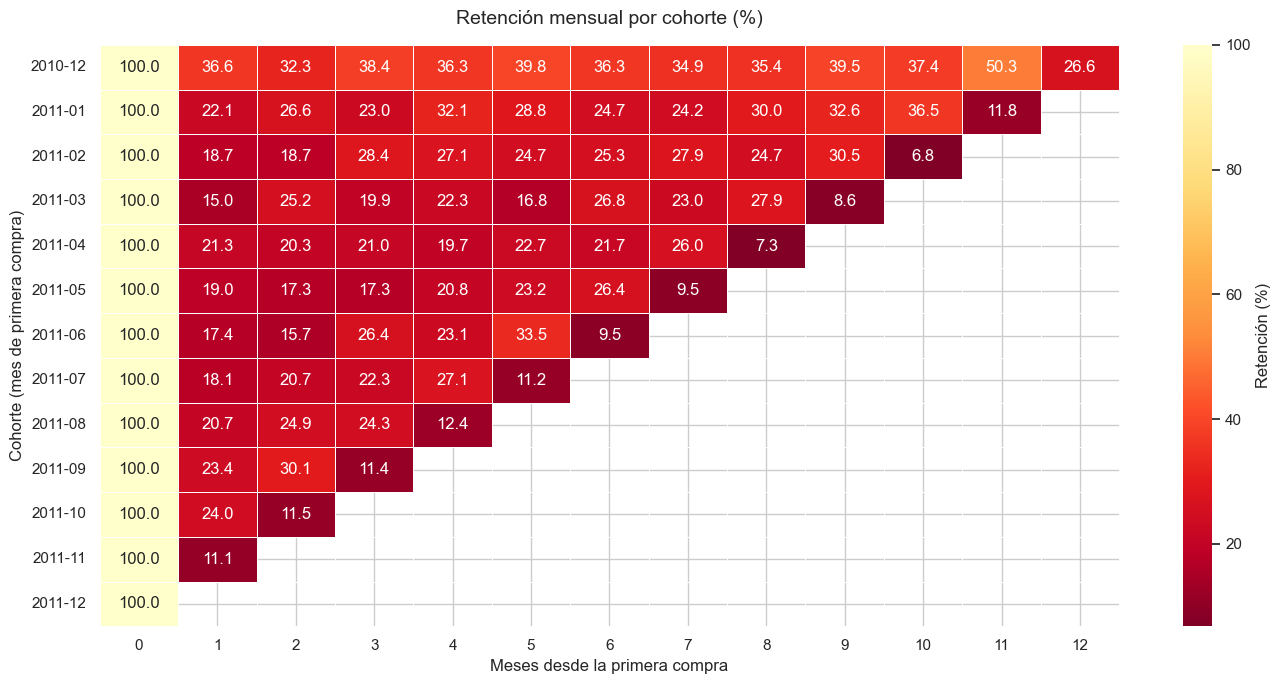

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retención (%)'},
    mask=retention.isnull()
)

ax.set_title('Retención mensual por cohorte (%)', pad=15)
ax.set_xlabel('Meses desde la primera compra')
ax.set_ylabel('Cohorte (mes de primera compra)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cohort_retention_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Análisis de Ventas

El análisis evalúa el rendimiento de ventas desde tres ángulos: 
por producto (revenue y volumen), y por mercado geográfico. 
Base: `df_clean`, que incluye todas las transacciones válidas 
independientemente de si el cliente está identificado.

---
### Top productos por revenue

In [6]:
product_sales = (
    df_clean
    .groupby('Description')
    .agg(
        revenue        = ('revenue', 'sum'),
        units_sold     = ('Quantity', 'sum'),
        invoice_count  = ('InvoiceNo', 'nunique')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

product_sales['avg_unit_price'] = (product_sales['revenue'] / product_sales['units_sold']).round(2)

print("Top 10 productos por revenue:")
print(product_sales.head(10).to_string(index=False))

Top 10 productos por revenue:
                       Description   revenue  units_sold  invoice_count  avg_unit_price
                    DOTCOM POSTAGE 206248.77         706            706          292.14
          REGENCY CAKESTAND 3 TIER 174156.54       13851           1988           12.57
       PAPER CRAFT , LITTLE BIRDIE 168469.60       80995              1            2.08
WHITE HANGING HEART T-LIGHT HOLDER 106236.72       37872           2256            2.81
                     PARTY BUNTING  99445.23       18283           1685            5.44
           JUMBO BAG RED RETROSPOT  94159.81       48371           2089            1.95
    MEDIUM CERAMIC TOP STORAGE JAR  81700.92       78033            247            1.05
                           POSTAGE  78101.88        3150           1126           24.79
                            Manual  77752.82        6985            290           11.13
                RABBIT NIGHT LIGHT  66870.03       30739            994            2.18


### Exclusión de entradas no comerciales

El ranking incluye registros que no representan productos reales: 
costos de envío (`DOTCOM POSTAGE`, `POSTAGE`) y entradas administrativas 
(`Manual`). Se excluyen para obtener el rendimiento real por producto.

`PAPER CRAFT , LITTLE BIRDIE` se mantiene en el análisis pero se 
señala como outlier: su revenue proviene de una única factura mayorista 
de 80.995 unidades, no de demanda recurrente.

In [7]:
non_products = ['DOTCOM POSTAGE', 'POSTAGE', 'Manual']

product_sales_clean = product_sales[
    ~product_sales['Description'].isin(non_products)
].reset_index(drop=True)

print("Top 15 productos por revenue (sin entradas no comerciales):")
print(product_sales_clean.head(15).to_string(index=False))

Top 15 productos por revenue (sin entradas no comerciales):
                       Description   revenue  units_sold  invoice_count  avg_unit_price
          REGENCY CAKESTAND 3 TIER 174156.54       13851           1988           12.57
       PAPER CRAFT , LITTLE BIRDIE 168469.60       80995              1            2.08
WHITE HANGING HEART T-LIGHT HOLDER 106236.72       37872           2256            2.81
                     PARTY BUNTING  99445.23       18283           1685            5.44
           JUMBO BAG RED RETROSPOT  94159.81       48371           2089            1.95
    MEDIUM CERAMIC TOP STORAGE JAR  81700.92       78033            247            1.05
                RABBIT NIGHT LIGHT  66870.03       30739            994            2.18
   PAPER CHAIN KIT 50'S CHRISTMAS   64875.59       19329           1160            3.36
     ASSORTED COLOUR BIRD ORNAMENT  58927.62       36362           1455            1.62
                     CHILLI LIGHTS  54096.36       10302    

### Visualización: Top 10 productos por revenue

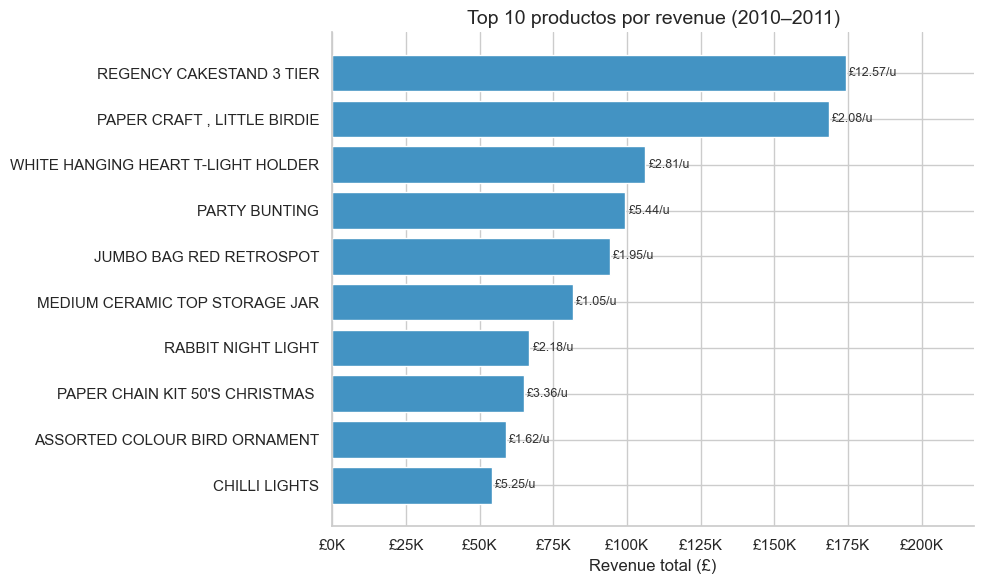

In [8]:
top10 = product_sales_clean.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10['Description'][::-1], top10['revenue'][::-1], color='#4393c3')

for bar, price in zip(bars, top10['avg_unit_price'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{price:.2f}/u',
            va='center', fontsize=9, color='#333333')

ax.set_xlabel('Revenue total (£)')
ax.set_title('Top 10 productos por revenue (2010–2011)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.set_xlim(0, top10['revenue'].max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'top10_products_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

### Análisis de ventas por mercado geográfico

UK representa el mercado principal. El objetivo de este análisis 
es cuantificar el peso relativo de los mercados secundarios e 
identificar aquellos con ticket promedio alto como candidatos 
a estrategias de expansión.

In [9]:
country_sales = (
    df_clean
    .groupby('Country')
    .agg(
        revenue          = ('revenue', 'sum'),
        transactions     = ('InvoiceNo', 'nunique'),
        avg_order_value  = ('revenue', 'mean')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

country_sales['revenue_pct'] = (country_sales['revenue'] / country_sales['revenue'].sum() * 100).round(2)

print("Todos los mercados:")
print(country_sales.to_string(index=False))

Todos los mercados:
             Country     revenue  transactions  avg_order_value  revenue_pct
      United Kingdom 9001744.094         18019        18.754220        84.59
         Netherlands  285446.340            94       121.003111         2.68
                EIRE  283140.520           288        35.936098         2.66
             Germany  228678.400           457        25.338327         2.15
              France  209625.370           392        24.979191         1.97
           Australia  138453.810            57       117.234386         1.30
               Spain   61558.560            90        24.832013         0.58
         Switzerland   57067.600            54        29.145863         0.54
             Belgium   41196.340            98        20.283772         0.39
              Sweden   38367.830            36        85.261844         0.36
               Japan   37416.370            19       116.561900         0.35
              Norway   36165.440            36        33

### Visualización: mercados secundarios

Se excluye UK para visualizar la distribución de los mercados 
secundarios. El ticket promedio por orden se superpone como 
métrica secundaria para identificar mercados de alto valor 
independientemente de su volumen actual.

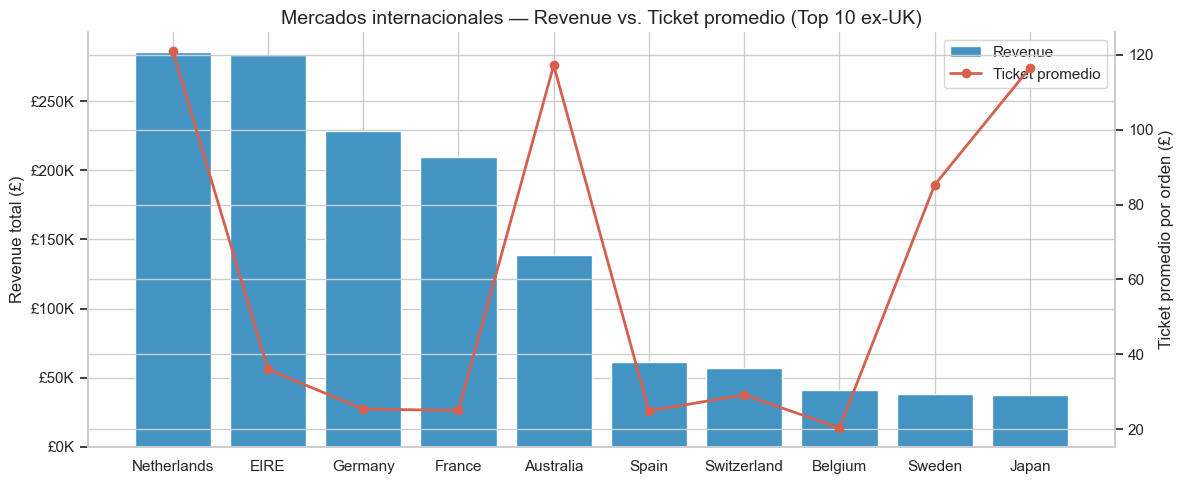

In [10]:
top_intl = country_sales[country_sales['Country'] != 'United Kingdom'].head(10)

fig, ax1 = plt.subplots(figsize=(12, 5))

bars = ax1.bar(top_intl['Country'], top_intl['revenue'], color='#4393c3', label='Revenue')
ax1.set_ylabel('Revenue total (£)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(top_intl['Country'], top_intl['avg_order_value'],
         color='#d6604d', marker='o', linewidth=2, label='Ticket promedio')
ax2.set_ylabel('Ticket promedio por orden (£)')

ax1.set_title('Mercados internacionales — Revenue vs. Ticket promedio (Top 10 ex-UK)')
plt.xticks(rotation=35, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

sns.despine(right=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'international_markets.png'), dpi=150, bbox_inches='tight')
plt.show()